In [435]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Data Cleaning**

In [436]:
df=pd.read_csv("googleplaystore.csv")
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [437]:
df.shape

(10841, 13)

In [438]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [439]:
df['Type'].unique()

array(['Free', 'Paid', nan, '0'], dtype=object)

In [440]:
df['Reviews']=pd.to_numeric(df['Reviews'],errors='coerce')
df['Reviews'].value_counts()

Reviews
0.0         596
1.0         272
2.0         214
3.0         175
4.0         137
           ... 
4272.0        1
5517.0        1
4057.0        1
459797.0      1
398307.0      1
Name: count, Length: 6001, dtype: int64

In [441]:
df[df.isnull()].sum()

App                 0
Category            0
Rating            0.0
Reviews           0.0
Size                0
Installs            0
Type                0
Price               0
Content Rating      0
Genres              0
Last Updated        0
Current Ver         0
Android Ver         0
dtype: object

In [442]:
df['Installs']=df['Installs'].str.replace('+',"",regex=False)
df['Installs']=df['Installs'].str.replace(',',"",regex=False)
df['Installs']=df['Installs'].str.replace('Free','0',regex=False)

In [443]:
df['Installs']=df['Installs'].astype(int)

In [444]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  int64  
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.1+ MB


In [445]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [446]:
df['Size']=df['Size'].str.replace('k',"000")
df['Size']=df['Size'].str.replace('M',"000000")
df['Size']=df['Size'].replace('Varies with device',np.nan)
df['Size'].value_counts()

Size
11000000    198
12000000    196
14000000    194
13000000    191
15000000    184
           ... 
429000        1
200000        1
460000        1
728000        1
619000        1
Name: count, Length: 461, dtype: int64

In [447]:
df['Size']=pd.to_numeric(df['Size'],errors='coerce')
df['Size']=df['Size'].fillna(df['Size'].mean())

In [448]:
df['Current Ver']=df['Current Ver'].replace('Varies with device',np.nan)
df[df['Current Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,2.500000e+07,50000000,Free,0,Teen,Art & Design,"June 8, 2018",NaN,4.2 and up
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55.0,2.700000e+00,5000,Free,0,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639.0,1.957748e+07,5000000,Free,0,Everyone,Art & Design,"July 14, 2018",NaN,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221.0,1.957748e+07,10000000,Free,0,Everyone,Art & Design,"July 30, 2018",NaN,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057.0,1.957748e+07,1000000,Free,0,Everyone,Auto & Vehicles,"July 30, 2018",NaN,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8.0,1.957748e+07,1000,Free,0,Everyone,Maps & Navigation,"September 27, 2017",NaN,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622.0,1.957748e+07,100000,Free,0,Mature 17+,Social,"May 23, 2018",NaN,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486.0,1.957748e+07,5000000,Free,0,Mature 17+,Social,"March 23, 2018",NaN,Varies with device
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114.0,1.957748e+07,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",NaN,Varies with device


In [449]:
df['Current Ver']=df['Current Ver'].fillna(0)
df['Current Ver']=pd.to_numeric(df['Current Ver'],errors='coerce')

In [450]:
df['Price'].value_counts()

Price
0         10040
$0.99       148
$2.99       129
$1.99        73
$4.99        72
          ...  
$1.75         1
$14.00        1
$4.85         1
$46.99        1
$1.04         1
Name: count, Length: 93, dtype: int64

In [451]:
df['Price']=df['Price'].str.replace('$','')
df['Price']=df['Price'].str.replace('Everyone','0')
df['Price']=df['Price'].astype(float)

**EDA**

In [452]:
df['Last Updated']=pd.to_datetime(df['Last Updated'],errors='coerce')

In [453]:
df['Rating'].unique()

array([ 4.1,  3.9,  4.7,  4.5,  4.3,  4.4,  3.8,  4.2,  4.6,  3.2,  4. ,
        nan,  4.8,  4.9,  3.6,  3.7,  3.3,  3.4,  3.5,  3.1,  5. ,  2.6,
        3. ,  1.9,  2.5,  2.8,  2.7,  1. ,  2.9,  2.3,  2.2,  1.7,  2. ,
        1.8,  2.4,  1.6,  2.1,  1.4,  1.5,  1.2, 19. ])

In [454]:
df['Rating']=df['Rating'].fillna(df['Rating'].mean())

In [455]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          10841 non-null  float64       
 3   Reviews         10840 non-null  float64       
 4   Size            10841 non-null  float64       
 5   Installs        10841 non-null  int64         
 6   Type            10840 non-null  object        
 7   Price           10841 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10841 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     5046 non-null   float64       
 12  Android Ver     10838 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(6)
memory usage: 1.1+ MB


<Axes: xlabel='Rating', ylabel='Type'>

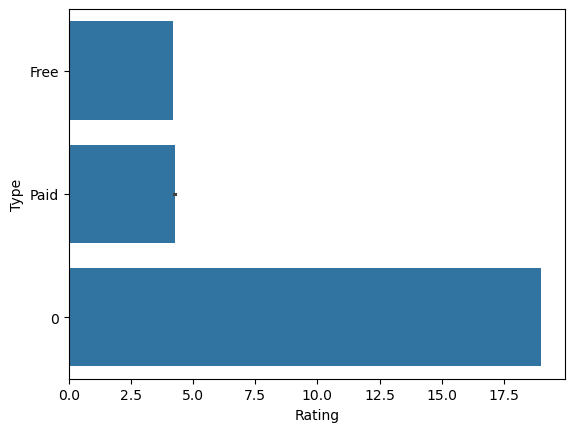

In [456]:
sns.barplot(x='Rating',y='Type',data=df)

<Axes: xlabel='Installs', ylabel='Count'>

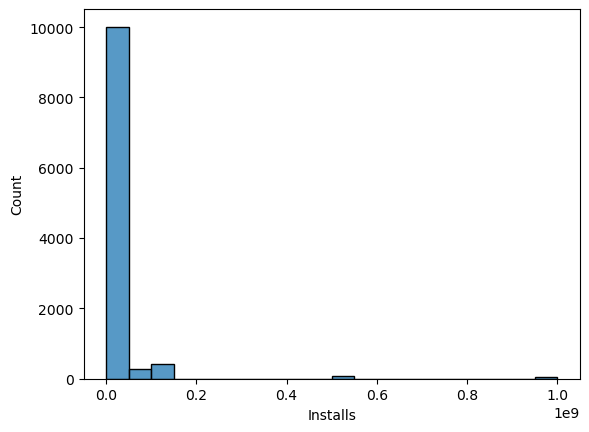

In [457]:
sns.histplot(x='Installs',data=df,bins=20)

<Axes: xlabel='Last Updated', ylabel='count'>

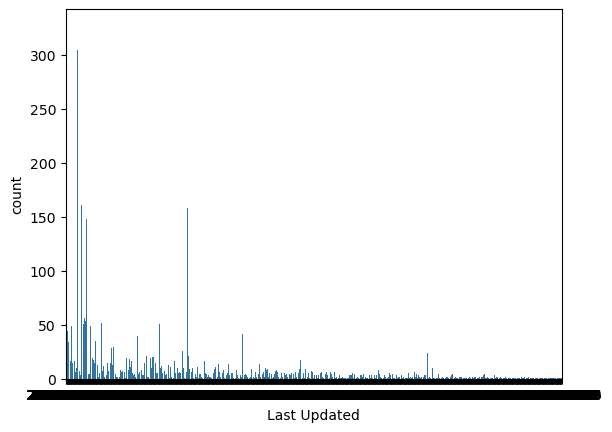

In [458]:
sns.countplot(x='Last Updated',data=df)

<Axes: xlabel='Installs', ylabel='count'>

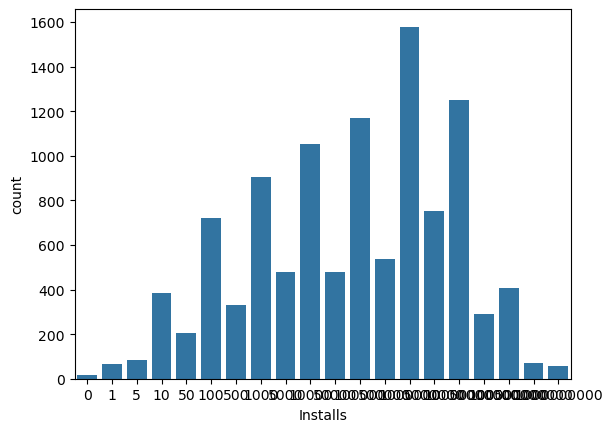

In [459]:
sns.countplot(x='Installs',data=df)